In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

## 7DT SED fit

In [7]:
from code.io import read_data
from code.analysis import Analyzer

from code.functions import *
from code.prior import *
from code.extinction import host_galaxy_extinction, host_galaxy_extinction_curve

In [9]:
df = read_data("sdt", correct_galactic_extinction=True, add_converted_flux=True)

eta = host_galaxy_extinction_curve(df["frequency_Hz"])
combined_func = lambda x, *params: power_law(x, *params[:2], x0=1e15) * host_galaxy_extinction(x, *params[2:], eta=eta)

param_bounds, prior = power_law_prior(data_type="sed")
param_bounds_ext, prior_ext = host_galaxy_extinction_prior()
param_bounds.update(param_bounds_ext)
prior.update(prior_ext)

alz_sed = Analyzer(df["frequency_Hz"], df["flux_mJy"], combined_func, data_type="sed", y_data_error=df["flux_error_mJy"], x_data_error=df["frequency_error_Hz"], param_bounds=param_bounds, prior=prior)
alz_sed.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-5e+01   [-52.1644..-52.1643]*| it/evals=4145/107629 eff=3.8620% N=300   0  00   0 0 
[ultranest] Likelihood function evaluations: 107665
[ultranest]   logZ = -61.4 +- 0.1357
[ultranest] Effective samples strategy satisfied (ESS = 1202.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.17 bs:0.14 tail:0.01 total:0.14 required:<0.50
[ultranest] done iterating.


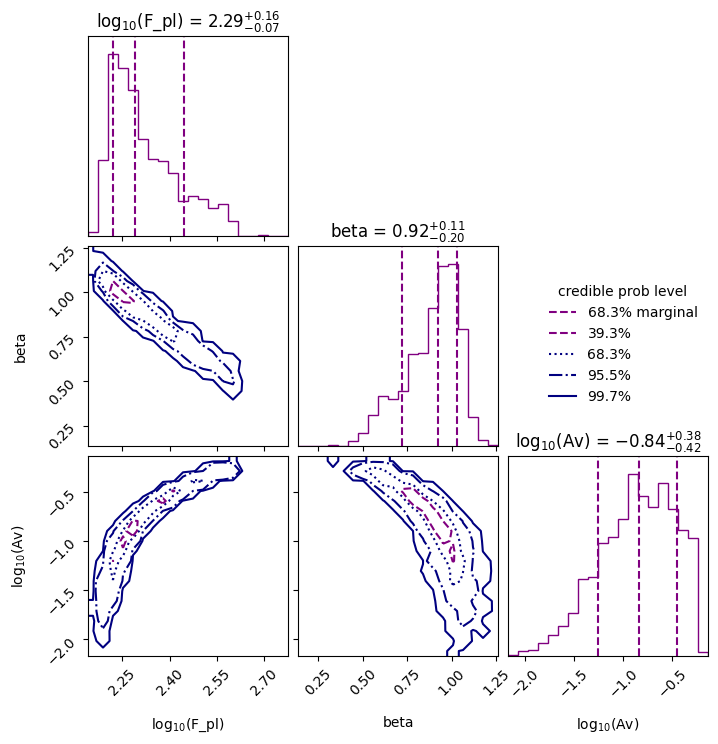

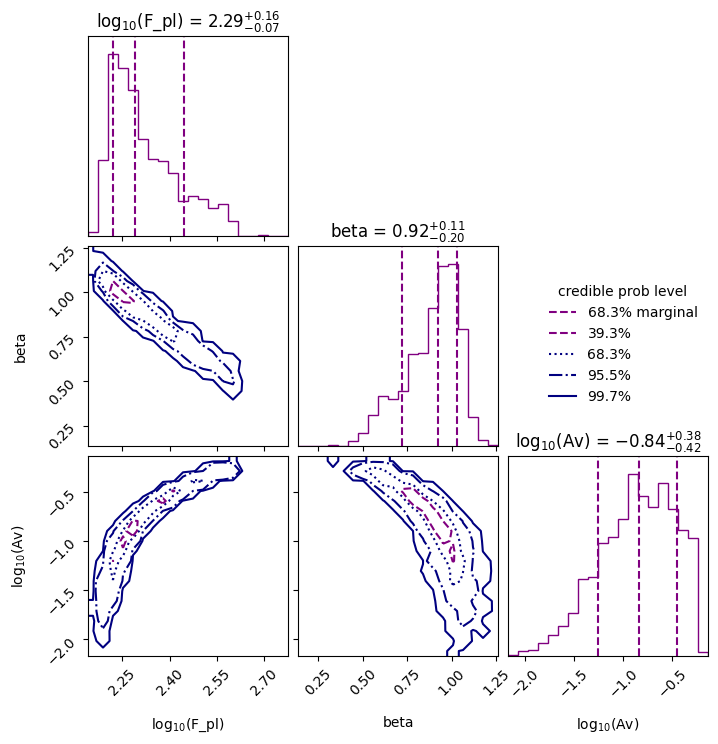

In [4]:
alz_sed.plot_corner()

<Axes: xlabel='Frequency', ylabel='Flux'>

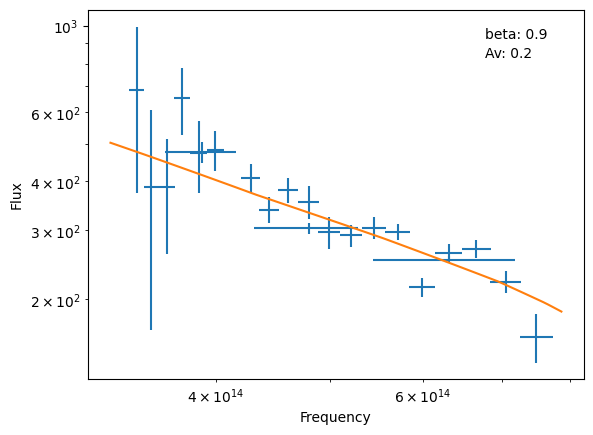

In [5]:
alz_sed.plot_data()
alz_sed.plot_model(show_param=True)


## XRT fit

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from code.io import read_data, filter_data
from code.const import TRIGGER_TIME
from code.analysis import Analyzer

from code.functions import *
from code.prior import *

In [7]:
df = read_data("xrt")
df = filter_data(df, exclude_time_range = (3e3,  1e4))
y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df["Flux_high"], df["Flux_low"])])

alz_xrt = Analyzer(df["Time"]/3600, df["Flux"], power_law, y_data_error=y_err)
alz_xrt.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-2e+01   [-19.8749..-19.8749]*| it/evals=4620/92678 eff=5.0012% N=300     0 0 0 0 0 
[ultranest] Likelihood function evaluations: 93166
[ultranest]   logZ = -30.75 +- 0.1506
[ultranest] Effective samples strategy satisfied (ESS = 1230.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.11 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.18 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.


## Ic band fit

In [10]:
from code.io import read_data, filter_data

In [14]:
df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["Ic"], remove_upper_limits=True, facility_name= "Leavitt\xa0")
alz_Ic = Analyzer(df["Time"], df["flux_mJy"], power_law, y_data_error=df["flux_error_mJy"])
alz_Ic.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-8e+01   [-77.5300..-77.5298]*| it/evals=4930/92588 eff=5.3420% N=300      0  0  
[ultranest] Likelihood function evaluations: 92615
[ultranest]   logZ = -89.39 +- 0.178
[ultranest] Effective samples strategy satisfied (ESS = 1213.2, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.19 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.


## i band fit

In [ ]:
filter_name = "i"

df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=filter_name, remove_upper_limits=True)

combined_func = lambda t, *params: power_law(t, *params[:2]) +  broken_power_law(t, *params[2:])

param_bounds, prior = power_law_prior()
param_bounds_bknpl, prior_bknpl = broken_power_law_prior()
param_bounds.update(param_bounds_bknpl)
prior.update(prior_bknpl)
# param_bounds["alpha_d"] = (alz_Ic.results["posterior"]["mean"][1], alz_Ic.results["posterior"]["stdev"][1])
# prior["alpha_d"] = "norm"

alz_i = Analyzer(df["Time"], df["flux_mJy"], combined_func, param_bounds=param_bounds, prior=prior, y_data_error=df["flux_error_mJy"])
alz_i.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-7e+01  6 [-70.2654..-70.2622]*| it/evals=19430/783456 eff=2.4810% N=300        0  0 
[ultranest] Likelihood function evaluations: 783456
[ultranest]   logZ = -133.2 +- 0.4215
[ultranest] Effective samples strategy satisfied (ESS = 854.2, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.10 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 298 minimum live points (dlogz from 0.33 to 1.13, need <0.5)
[ultranest]   logZ error budget: single: 0.45 bs:0.42 tail:0.35 total:0.55 required:<0.50
[ultranest] done iterating.


## Rc band fit

In [ ]:
from code.functions import smooth_broken_power_law


df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["Rc"], remove_upper_limits=True, facility_name= "Leavitt\xa0")

alz_Rc = Analyzer(df["Time"], df["flux_mJy"], power_law, y_data_error=df["flux_error_mJy"])
alz_Rc.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-4e+02  .65 [-350.6580..-350.6579]*| it/evals=5652/118294 eff=4.7901% N=300    0      
[ultranest] Likelihood function evaluations: 118568
[ultranest]   logZ = -364.9 +- 0.1972
[ultranest] Effective samples strategy satisfied (ESS = 1152.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.20, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.
Rc [0.003811474638082948, 1.3357691628763726]


## r/ r' bands fit

In [ ]:
df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["r", "r'"], remove_upper_limits=True, exclude_time_range=(20, 1e4))

alz_r = Analyzer(df["Time"], df["flux_mJy"], broken_power_law, y_data_error=df["flux_error_mJy"])
alz_r.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-1e+01   [-12.2717..-12.2714]*| it/evals=7980/304431 eff=2.6239% N=300 0  00   0  
[ultranest] Likelihood function evaluations: 304871
[ultranest]   logZ = -34.28 +- 0.1763
[ultranest] Effective samples strategy satisfied (ESS = 1677.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.26 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.


## g band fit

In [67]:
df = read_data("circular", add_converted_flux=False)
df = filter_data(df, filter_name=["g"], remove_upper_limits=True, exclude_time_range=(20, 1e4))
df = mag_to_flux_jy(df)
alz_g = Analyzer(df["Time"], df["flux_mJy"], power_law, y_data_error=df["flux_error_mJy"])
alz_g.run()

KeyError: 0

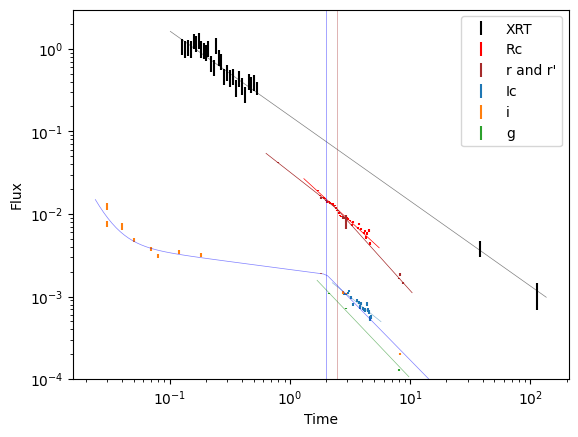

In [87]:
alz_xrt.plot_data(scale=1e10, color="k", label="XRT")
alz_xrt.plot_model(color="k", scale=1e10, lw=0.5, alpha=0.5)

alz_Rc.plot_data(scale=10, color="red", label="Rc")
alz_Rc.plot_model(color="red", scale=10, lw=0.5)

alz_r.plot_data(scale=10, color="brown", label="r and r'")
alz_r.plot_model(color="brown", scale=10, lw=0.5)
plt.axvline(alz_r.best_fit_params[1], color="brown", lw=0.5, alpha=0.5)

alz_Ic.plot_data(label="Ic")
alz_Ic.plot_model(color="C0", lw=0.5, alpha=0.5)

alz_i.plot_data(label="i")
alz_i.plot_model(color="blue", lw=0.5, alpha=0.5)
plt.axvline(alz_i.best_fit_params[3], color="blue", lw=0.5, alpha=0.5)


alz_g.plot_data(label="g")
alz_g.plot_model(color="green", lw=0.5, alpha=0.5)


plt.legend()

plt.ylim(1e-4,)
plt.show()

In [89]:
print("XRT", alz_xrt.best_fit_params)
print("Rc", alz_Rc.best_fit_params)
print("r", alz_r.best_fit_params)
print("Ic", alz_Ic.best_fit_params)
print("i", alz_i.best_fit_params)
print("g", alz_g.best_fit_params)


XRT [1.5325032950404544e-11, 1.0292361934504495]
Rc [0.003811474638082948, 1.3357691628763726]
r [0.0011593132062532535, 2.4412438785450163, 1.1402459187995233, 1.6204672660992312]
Ic [0.0037680984270095437, 1.1628391170605388]
i [3.9455187529761485e-08, 3.3518121597601214, 0.0018330686386611782, 2.0028779701609687, 0.1918698900659035, 1.4866259171789453, 0.014432032371887834]
g [0.0034729198838764318, 1.529040299483159]
